## Imports and Helper Functions

The following cell imports all the necessary packages used throughout this notebook. Moreover, the "plot_quartier_chloropleth" and "build_annotation" function is also defined here to avoid repitition of the same plotting code in some questions. 

In [1]:
!pip install cmcrameri 

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cmcrameri.cm as cmc
from shapely import wkt

In [2]:
def plot_quartier_choropleth(gdf, column, cmap, colorbar_title, map_title, annotation, label_col="label", vmax=None):
    fig, ax = plt.subplots(figsize=(12, 10))
    gdf.plot(column=column, cmap=cmap, legend=True, edgecolor="black", ax=ax, vmax=vmax)
    ax.get_figure().axes[1].set_title(colorbar_title, fontsize=8, pad=8)
    for _, row in gdf.iterrows():
        middle_point = row.geometry.representative_point()
        ax.text(middle_point.x, middle_point.y, str(row[label_col]), ha="center", fontsize=7)
    fig.text(0.5, -0.0005, annotation, ha="center", va="top", fontsize=7, transform=fig.transFigure)
    ax.set_title(map_title)
    ax.axis("off")
    return fig, ax

In [3]:
def build_annotation(gdf, entry_template, entries_per_line):
    entries = [
        entry_template(row)
        for _, row in gdf.iterrows()
    ]
    lines = []
    for i in range(0, len(entries), entries_per_line):
        chunk = entries[i:i + entries_per_line]
        lines.append("  |  ".join(chunk))
    return "\n".join(lines)

## Data Exploration & Cleaning

In [4]:
df = pd.read_csv("../data/raw/stzh.zwn_meldungen_p.csv") #importing the dataset and calling it "df"
df.head()


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14T15:16:15,2013-04-04T07:25:05,2013-04-12T07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14T15:17:57,2013-03-26T14:05:05,2013-04-12T08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15T09:14:16,2013-03-15T09:55:05,2013-04-12T08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15T09:17:15,2013-03-20T10:05:05,2013-04-12T08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15T10:36:53,2013-04-22T18:25:05,2013-04-23T13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


Now I have the data, I want to check to find where the types of incidents are listed(graffiti, vandalism, etc.), so:

In [5]:
df["service_name"].unique() #unique values in service_name

<ArrowStringArray>
[   'Strasse/Trottoir/Platz',       'Abfall/Sammelstelle',
   'Grünflächen/Spielplätze',         'Beleuchtung/Uhren',
                  'Graffiti', 'Signalisation/Lichtsignal',
         'Brunnen/Hydranten',                    'VBZ/ÖV',
                 'Allgemein',                'Schädlinge']
Length: 10, dtype: str

In [6]:
df["geometry"].head() #spatial geometry of point of each incident


0    POINT (2678968 1247548)
1    POINT (2680746 1249916)
2    POINT (2684605 1251431)
3    POINT (2681754 1250376)
4    POINT (2683094 1247762)
Name: geometry, dtype: str

Each incident has a geographical point location, likely using Swiss projection coordinates(e.g. Swiss CRS EPSG: 2056 projection). Also "dtype:str" signals that the data is stored in the form of text strings, thus will need to be transformed into spatial objects. This means transforming the dataframe into a GeoDataFrame, so that these text strings can be converted to real geographical locations and can be mapped or spatially joined.

In [7]:
df["service_name"].value_counts() #number of incidents for each event

service_name
Abfall/Sammelstelle          27445
Signalisation/Lichtsignal    10984
Strasse/Trottoir/Platz        9874
Grünflächen/Spielplätze       7254
Beleuchtung/Uhren             5414
Allgemein                     3977
Graffiti                      3780
VBZ/ÖV                        1886
Brunnen/Hydranten             1295
Schädlinge                     895
Name: count, dtype: int64

For this analysis, relevant columns are "requested_datetime", "service_name","geometry", and perhaps "title" and "status"

In [8]:
cleaned_df = df[["requested_datetime", "service_name","status","title","geometry"]] #creating the new dataset with
#relevant columns
cleaned_df.head()

,requested_datetime,service_name,status,title,geometry
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548)
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916)
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431)
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376)
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762)


Now we have the dataframe with the relevant columns, we can convert the text strings into geometry objects using functionality from GeoPandas and Well-Known Text from Shapely, so:

In [9]:
cleaned_df["geometry"] = cleaned_df["geometry"].apply(wkt.loads) #this converts text strings into Shapely Points

The error shows how it was expected to be working with bytes or strings but it actually was Point data in the geometry column, signalling that the dataset is already close to a GeoDataFrame. Now we can create the GeoDataFrame, so:

In [10]:
zurich_gdf = gpd.GeoDataFrame(cleaned_df, geometry="geometry", crs="EPSG:2056") # added CRS so it is usable in other systems(according to error)

type(zurich_gdf)#verify that the type of the dataset is a GeoDataFrame

geopandas.geodataframe.GeoDataFrame

<Axes: >

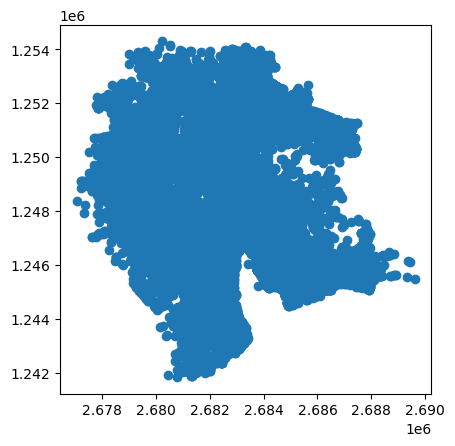

In [11]:
zurich_gdf.plot()#the data is working when we map it too

In [12]:
zurich_gdf.to_file("../data/processed/zurich_gdf.gpkg") #save the data to the folder to work with later

## Importing Zurich district polygons for spatial joining

Now that the GeoDataFrame of point data per incident has been created, it can be spatially joined to begin analyzing incidents across different areas of Zurich. Thus, we will therefor need polygon data of areas in Zurich for analysis. To do this, the "Statistische Quartier" geopackage was chosen which includes polygons of each quartier of Zurich. This will allow us to sort the incidents into their respective quartier. 

In [13]:
zurich_quartier_polygons = gpd.read_file("../data/raw/data.gpkg")

C:\Users\Emily Rose\miniconda3\envs\sds-env\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'data.gpkg': 'stzh.adm_statistische_quartiere_b_p' (default), 'stzh.adm_statistische_quartiere_v', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


Now lets inspect the dataset

In [14]:
zurich_quartier_polygons.head()

,objid,objectid,ori,hali,vali,name,kuerzel,geometry
0,1,1,0.0,1.0,2.0,Affoltern,111,POINT (2680575.711 1253034.933)
1,2,2,0.0,1.0,2.0,Seebach,119,POINT (2683071.957 1253148.375)
2,3,3,0.0,1.0,2.0,Saatlen,121,POINT (2684968.446 1251835.404)
3,4,4,0.0,1.0,2.0,Höngg,101,POINT (2679781.451 1251349.147)
4,5,5,0.0,1.0,2.0,Wipkingen,102,POINT (2681888.652 1250165.853)


In [15]:
zurich_quartier_polygons.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [16]:
zurich_quartier_polygons.geom_type.unique()

<ArrowStringArray>
['Point']
Length: 1, dtype: str

The CRS is indeed correct, as was listed on the dataset website. However, the dataset is listed as point data. The user warning after creating the zurich_quartier_polygons object indicates that there is more than one layer in the dataset, and this point layer is likely denoting the centroid of each quartier. Therefore, we must select the correct layer associated with the quartier polygons themselves. The likely layer is "stzh.adm_statistische_quartiere_map", so we select it when defining the object.

In [17]:
zurich_quartier_polygons = gpd.read_file("../data/raw/data.gpkg", layer="stzh.adm_statistische_quartiere_map")

Now we check the geometry type to see if its polygon data.

In [18]:
zurich_quartier_polygons.geom_type.unique()

<ArrowStringArray>
['Polygon']
Length: 1, dtype: str

Now we see it is the polygon layer, and we can plot it to see if it actually is the quartier polygons.

<Axes: >

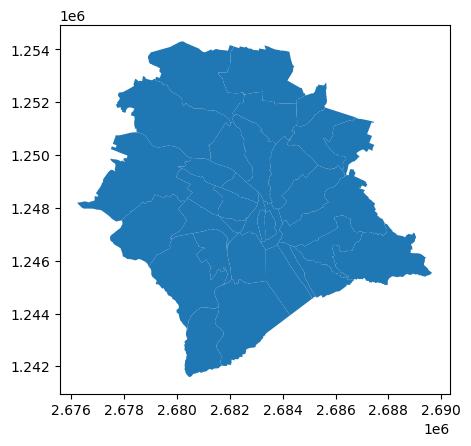

In [19]:
zurich_quartier_polygons.plot()

It is the correct layer, now we just double-check that both the incident point data and the polygon data are in the same CRS before spatially joining them.

In [20]:
zurich_gdf.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [21]:
zurich_quartier_polygons.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

They are both in the same CRS(EPSG: 2056) and are ready for spatial joining. This joint dataset will be the main foundational dataset for this analysis, so we must assure quality and give it a representative name. 

In [22]:
zurich_qi = gpd.sjoin( #spatially join the two datasets, "qi" is quartier incidents
    zurich_gdf, zurich_quartier_polygons,
    how = "left", #keep all the incident data points, even if some dont fall in a polygon
    predicate = "within" #describes to find which polygon each point falls within
) 

Now we check the joined dataframe to see if we have each incident(service_name) with an associated neighbourhood(qname).

In [23]:
zurich_qi.head()

,requested_datetime,service_name,status,title,geometry,index_right,objectid,qnr,qname,knr,kname
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548),6.0,9.0,91.0,Albisrieden,9.0,Kreis 9
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916),10.0,19.0,101.0,Höngg,10.0,Kreis 10
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431),26.0,26.0,121.0,Saatlen,12.0,Kreis 12
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376),21.0,17.0,102.0,Wipkingen,10.0,Kreis 10
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762),22.0,22.0,14.0,City,1.0,Kreis 1


We must also save this new joined dataset too.

In [24]:
zurich_qi.to_file("../data/processed/incidents_joined_quartiers.gpkg", driver = "GPKG")

Now that we have the spatially joined dataset with incidents organized into their associated quartier, we can begin working on answering questions about the data and creating outputs like maps and figures.

# Question 1: Which quartiers receive the highest number of total reports?

In order to answer this question, we must follow a structured workflow. First, we must count the total reports within each quartier and create a dataframe of this. Then we must merge this dataset with the polygon dataset. Finally, we will make a chloropleth map using the plot_quartier_chloropleth function defined earlier to visualize these results.

#### Step 1: Creating a dataframe of reports per quartier

We want to group all the incidents by quartier name and count them:

In [25]:
report_counts = zurich_qi.groupby("qname").size()

Then we want to convert this to a dataframe, as groupby().size() creates a series where quartier names are stored as indexes in the series and not a normal column. We therefor convert this to a dataframe so it can be easily merged with the polygon data. 

In [26]:
report_counts = report_counts.reset_index(name="report_count") #.reset_index() tells python to take this index and reset it back 
#to a column

Now we check the report_counts dataset

In [27]:
report_counts.head()

,qname,report_count
0,Affoltern,2427
1,Albisrieden,2035
2,Alt-Wiedikon,2517
3,Altstetten,4122
4,City,1742


Now that its properly formatted and ready to go, we can merge it with the quartier polygon dataset

In [28]:
quartier_report_counts = zurich_quartier_polygons.merge(
    report_counts,
    on="qname"
)

Check that the dataset is properly merged

In [29]:
quartier_report_counts.head()

,objectid,qnr,qname,knr,kname,geometry,report_count
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315...",1384
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291...",810
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684269.913 1246566.796, 2684271.618...",912
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.254 1246609.895, 2683802.117...",1283
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682651.888 1247587.653, 2682650.697...",1576


We now have all the required columns for creating the chloropleth map (qname, geometry, report_count)

#### Step 2: Creating a chloropleth map of total reports per quartier

An appropriate way to visualize the numner of reports in each quartier and compare them is through a cholorpleth map. This assigns each total report number a color along a color scale, with darker shades typically representing high total reports and lighter shades representing low total reports. We can also assign a label to each quartier polygon, and then display a table underneath the map that tells us which label corresponds to which quartier, as well as provide the total reports for that quartier too.

We can do all of this by calling the plot_quartier_chloropleth function we defined earlier to produce a map. However, there are some prerequisites to this. We must first assign a numeric lable to each quartier for it to be properly labelled on the map itself, and must also build the annotation text to go below the map by calling the build_annotation function defined earlier. We pass both of these into the plot_quartier_chloropleth function, along with other stylistic choices, to produce a chloropleth map of the total urban issue reports per quartier. 

In [30]:
#create a column for a numeric label for each quartier polygon
quartier_report_counts["label"] = range(1, len(quartier_report_counts) + 1)

quartier_label_table = quartier_report_counts[
    ["label", "qname", "report_count"]#selects the relevant columns from quartier_report_counts for the table
    ].sort_values("label")#sort the table by their label values rather than their index values

quartier_label_table.head()

,label,qname,report_count
0,1,Hirslanden,1384
1,2,Weinegg,810
2,3,Mühlebach,912
3,4,Seefeld,1283
4,5,Werd,1576


Now that we have the table with the label and its corresponding quartier and report_count value, we start creating the annotation we want to show beneath the map. 

In [31]:
annotation_q1 = build_annotation(
    quartier_label_table,
    lambda row: f"{row['label']} - {row['qname']} - {row['report_count']} reports",
    entries_per_line=6
)

With both the labelling and annotation done, we can now pass these to the plot_quartier_chloropleth function to produce the map.

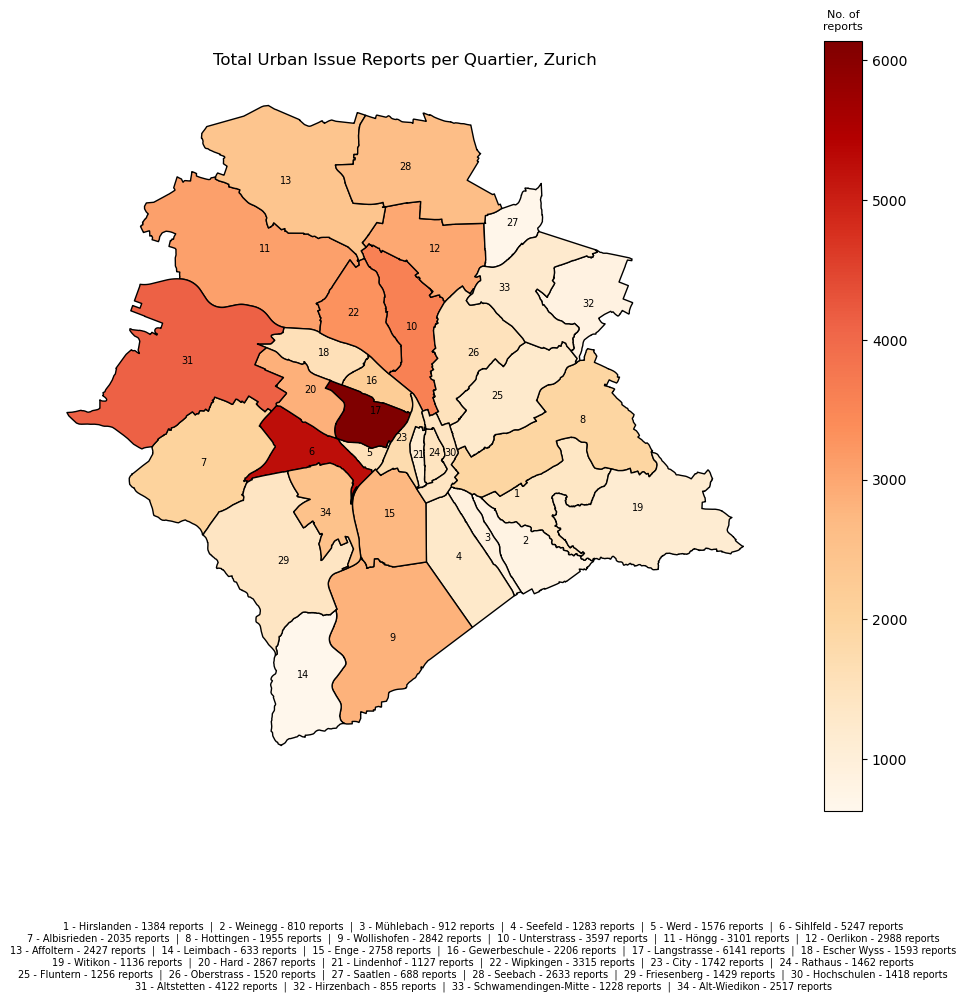

In [32]:
fig, ax = plot_quartier_choropleth(
    quartier_report_counts, "report_count", "OrRd",
    "No. of\nreports", "Total Urban Issue Reports per Quartier, Zurich",
    annotation_q1
)

Now that we have created the final map, we can save it to the outputs folder.

In [33]:
fig.savefig(
    "../outputs/total_reports_per_quartier_chloropleth.png", #save it in outputs
    dpi=300,
    bbox_inches="tight")#expand image to fit all content in the figure, so that none is cut off
    

## Question 2: Which categories of reports are most common in Zurich? 

For this question, the plan is to create 2 outputs; a bar chart visualization of citywide urban issue category frequency, and a map showing the dominant issue type in each quartier. 

#### Step 1: Translate all the urban issue types to English

First, we will translate the urban issue categories from the service_name column in the zurich_qi dataset to english. To do this, we will keep the original column but add a new column for the english translations. So first we will list all the service names.

In [34]:
zurich_qi["service_name"].value_counts()

service_name
Abfall/Sammelstelle          27445
Signalisation/Lichtsignal    10984
Strasse/Trottoir/Platz        9874
Grünflächen/Spielplätze       7254
Beleuchtung/Uhren             5414
Allgemein                     3977
Graffiti                      3780
VBZ/ÖV                        1886
Brunnen/Hydranten             1295
Schädlinge                     895
Name: count, dtype: int64

Now we can see we have 10 different urban issue categories we need to translate.

In [35]:
#create the translations:
translations = {
    "Abfall/Sammelstelle":"Waste/Collection Point",
    "Signalisation/Lichtsignal":"Light signals/Traffic Signals/Signs",
    "Strasse/Trottoir/Platz":"Street/Pavement/Square",
    "Grünflächen/Spielplätze":"Green Spaces/Playground",
    "Beleuchtung/Uhren":"Lights/Clocks",
    "Allgemein":"General",
    "Graffiti":"Graffiti",
    "VBZ/ÖV":"Public Transport",
    "Brunnen/Hydranten":"Fountains/Fire Hydrants",
    "Schädlinge":"Pests"
}

Then we add English category column to zurich_qi.

In [36]:
zurich_qi["service_name_english"] = (
    zurich_qi["service_name"].map(translations))
#.map() tells python to replace each German category from service_name with the English ones from translations

zurich_qi.head()

zurich_qi["service_name_english"].value_counts()

service_name_english
Waste/Collection Point                 27445
Light signals/Traffic Signals/Signs    10984
Street/Pavement/Square                  9874
Green Spaces/Playground                 7254
Lights/Clocks                           5414
General                                 3977
Graffiti                                3780
Public Transport                        1886
Fountains/Fire Hydrants                 1295
Pests                                    895
Name: count, dtype: int64

#### Step 2: Create the barchart

Now that we have the category names in English, we can do a citywide category analysis through creating a bar chart of number of reports per urban issue category. For this, we need to count the total reports per category, store these counts, and plot them as a bar chart, customizing the chart to improve presentation and readability.

In [37]:
#count the number of reports per category
category_report_counts = (
    zurich_qi["service_name_english"].value_counts() #value_counts() for frequency of categories
)

category_report_counts.head()

service_name_english
Waste/Collection Point                 27445
Light signals/Traffic Signals/Signs    10984
Street/Pavement/Square                  9874
Green Spaces/Playground                 7254
Lights/Clocks                           5414
Name: count, dtype: int64

Now that we have the total reports per category in English, we can begin plotting the bar chart.

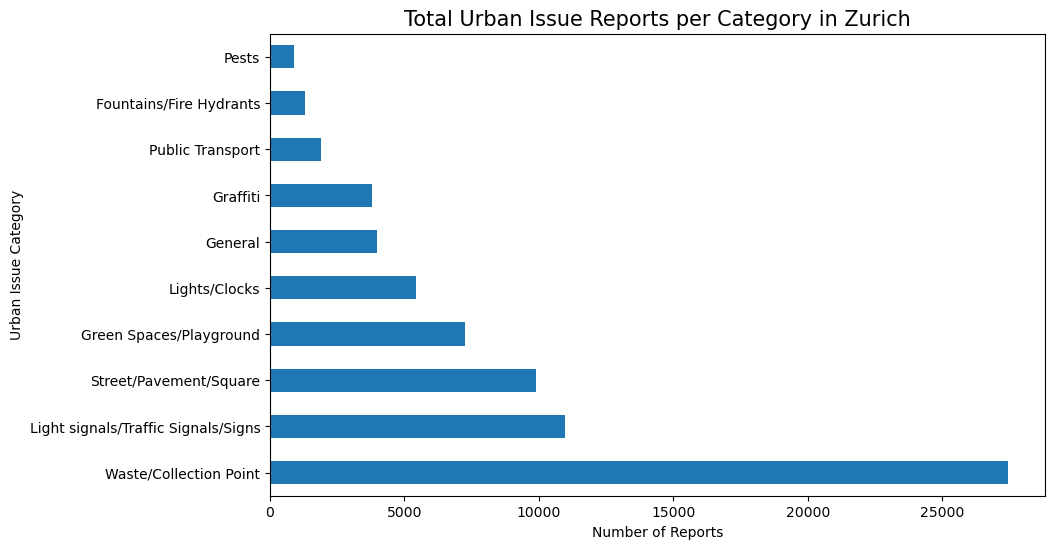

In [38]:
#create the figure and axes
fig, ax = plt.subplots(figsize=(10,6))

#plot the bar chart horizontally
category_report_counts.plot(
    kind="barh", #horizontal bar chart
    ax=ax
)
#add title and axes titles
ax.set_title(
    "Total Urban Issue Reports per Category in Zurich",
    fontsize=15
)
ax.set_xlabel("Number of Reports")
ax.set_ylabel("Urban Issue Category")

#show the figure
plt.show()

Now we can save the figure in the outputs folder.

In [39]:
fig.savefig(
    "../outputs/issue_reports_per_category_barchart.png",
    dpi=300,
    bbox_inches="tight"
)

#### Step 3: Which categories of reports are most common in each quartier?

To visualize the most common urban issue report category in each quartier, we can assign each category a color and then make each quartier polygon the color of their most common category. First, we count the number of reports per category in each quartier, then identify the most common issue category from this, then merge these results into the quartier polygons so that we can map quartiers to represent their dominant category.

In [40]:
#count categories in each quartier
quartier_category_counts = (
    zurich_qi
    .groupby(["qname","service_name_english"]) #group rows that share same quartier and service_name_english
    .size() #how many rows are inside each group (frequency count)
    .reset_index(name="count") #.size() returns a series, not a normal dataframe, so we group it to get a clean dataframe
#name the column "count" otherwise it would be named 0
)

quartier_category_counts.head()

,qname,service_name_english,count
0,Affoltern,Fountains/Fire Hydrants,30
1,Affoltern,General,109
2,Affoltern,Graffiti,133
3,Affoltern,Green Spaces/Playground,308
4,Affoltern,Light signals/Traffic Signals/Signs,376


Now we must identify the dominant category per quartier, so we only want the category with the highest count value

In [41]:
quartier_dominant_category = (
    quartier_category_counts
    .sort_values("count", ascending=False)#sorts count values in descending order
    .drop_duplicates("qname")#this removes all rows after the first one for each quartier
)

quartier_dominant_category.head()
quartier_dominant_category["service_name_english"].unique()

<ArrowStringArray>
['Waste/Collection Point', 'Green Spaces/Playground',
 'Street/Pavement/Square']
Length: 3, dtype: str

We can now begin assigning colors to each urban issue category to prepare it for mapping. First we will define the colors per category, then we will add the color column to the dataframe. Since there are only 3 unique values, we can define the colors manually.

In [42]:
category_colors = {
    "Waste/Collection Point":"orange",
    "Green Spaces/Playground":"blue",
    "Street/Pavement/Square":"yellow"
}

Now we add the color column to the dataframe.

In [43]:
quartier_dominant_category["color"] = (
    quartier_dominant_category["service_name_english"].map(category_colors)#assign each row its color
)

quartier_dominant_category.head()

,qname,service_name_english,count,color
169,Langstrasse,Waste/Collection Point,3830,orange
279,Sihlfeld,Waste/Collection Point,3154,orange
109,Hard,Waste/Collection Point,1630,orange
39,Altstetten,Waste/Collection Point,1415,orange
29,Alt-Wiedikon,Waste/Collection Point,1281,orange


Now we create the geodataframe which merges the quartier polygons with qname, service_name_english, count, and color. We also must not forget the label column too. 

In [44]:
quartier_colored_categories = zurich_quartier_polygons.merge(
    quartier_dominant_category,
    on="qname",
    how="left"
)[["qname", "service_name_english", "count", "color", "geometry", ]]#only includes these columns

quartier_colored_categories["label"] = range(
    1, 
    len(quartier_colored_categories) + 1
) #len() counts number of rows in the dataframe. we add +1 because range stops 
#before the last number its given(e.g. range(1, 5) gives numbrs 1 to 4, so +1 fixes this)


quartier_colored_categories.head()

,qname,service_name_english,count,color,geometry,label
0,Hirslanden,Waste/Collection Point,477,orange,"POLYGON ((2684457.034 1246514.804, 2684466.315...",1
1,Weinegg,Waste/Collection Point,254,orange,"POLYGON ((2684457.383 1246512.719, 2684458.291...",2
2,Mühlebach,Waste/Collection Point,389,orange,"POLYGON ((2684269.913 1246566.796, 2684271.618...",3
3,Seefeld,Waste/Collection Point,512,orange,"POLYGON ((2683794.254 1246609.895, 2683802.117...",4
4,Werd,Waste/Collection Point,961,orange,"POLYGON ((2682651.888 1247587.653, 2682650.697...",5


#### Step 4: Creating the map of most common reported issues per quartier

With this dataframe, we can now map the most common urban issue in each quartier. This will not be a chloropleth map, so the plot_quartier_chloropleth function does not apply here, but it will follow a similar though process. First, we will follow the same annotation approach used in Question 1's map, utilizing the build_annotation function defined earlier. 

In [45]:
annotation_q2 = build_annotation(
    quartier_colored_categories,
    lambda row: f"{row['label']} - {row['qname']} - {row['service_name_english']} - {row['count']} reports",
    entries_per_line=4
)

Now we can create the annotated map. We must also add a legend to the figure for presentation and readability.

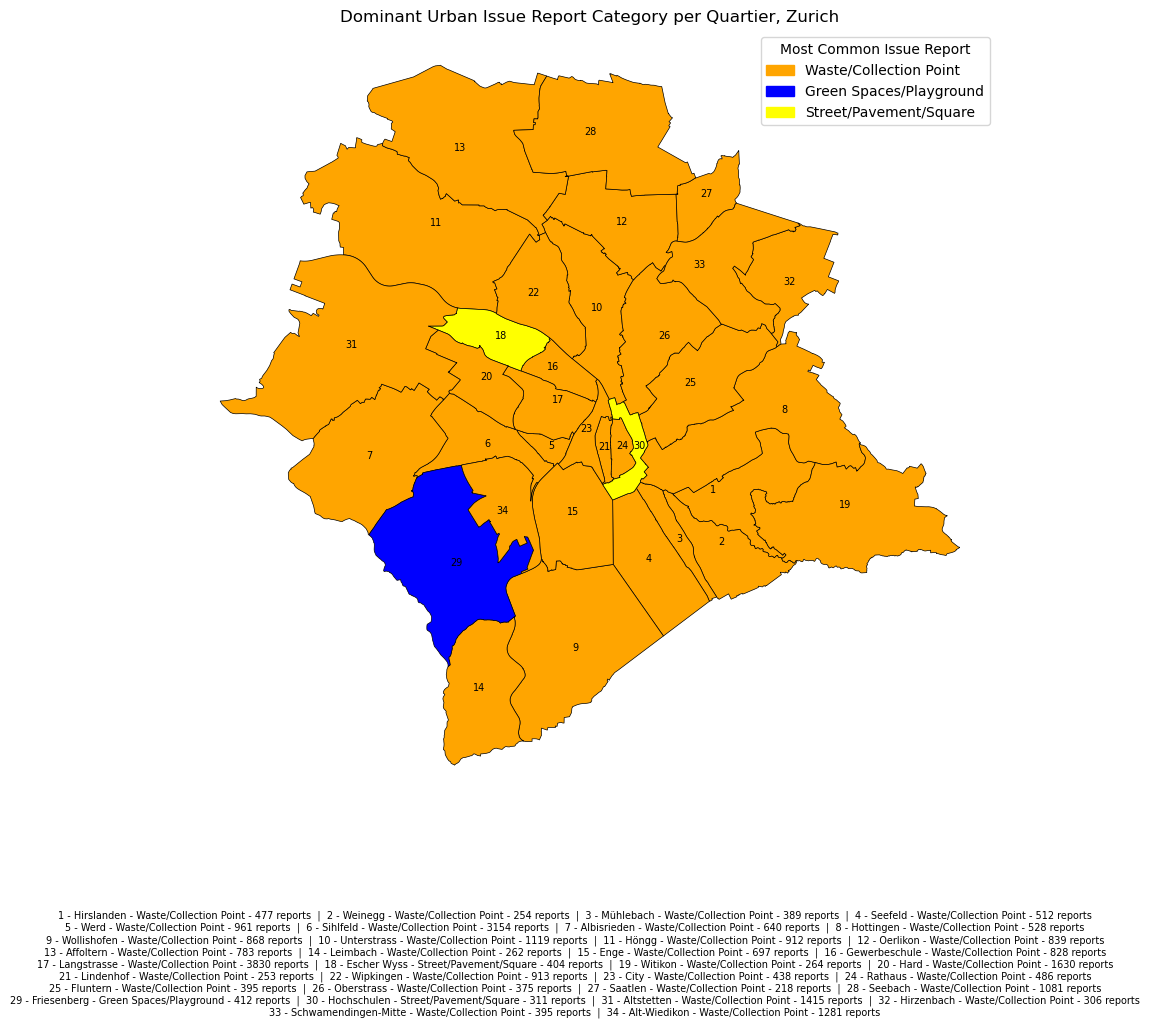

In [46]:
# figure axis
fig, ax = plt.subplots(figsize=(12, 10))
quartier_colored_categories.plot(
    color=quartier_colored_categories["color"],
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

#now we add label numbers to the centroid of each quartier polygon
for idx, row in quartier_colored_categories.iterrows(): #tells python go through every row in the dataframe(idx is row number, rows contain values)
        middle_point = row.geometry.representative_point() #guarantees the point is inside the polygon, specifically designed for such sitations
        ax.text( #draw text on the map at the coordinates of each polygon centroid
            middle_point.x,#now the representative point coordinates rather than the centroid coordinates
            middle_point.y,
            str(row["label"]),#make row number the label of the polygon, str() used to convert labels from numbers to strings so matplotlib can process them
            ha="center", #horizontal alignment of the label is at the center, number on centroid point
            fontsize=7)

#add the annotation below the map
fig.text(
    0.5, #centered on x-axis
    -0.0005, #just below the y-axis
    annotation_q2, 
    ha="center",
    va="top",
    fontsize=7,
    transform=fig.transFigure
)

#add the legend to the top left of the figure
legend_patches = []
for cat, color in category_colors.items():
    patch = mpatches.Patch(color=color, label=cat)
    legend_patches.append(patch)
ax.legend(handles=legend_patches, title="Most Common Issue Report", loc="upper right")

#set the title and remove clutter
ax.set_title("Dominant Urban Issue Report Category per Quartier, Zurich")
ax.axis("off")
plt.show()

Now we can save this map to the outputs folder

In [47]:
fig.savefig(
    "../outputs/dominant_issue_report_category_per_quartier.png",
    dpi=300,
    bbox_inches="tight"
)

## Question 3: Which quartiers have the highest number of reports per capita?

We know now which quartiers have the highest amount of total urban issue reports, but this could be due to the higher population in these quartiers. Thus, we must also consider the number of reports per person in each quartier to get a better understanding of if some quartiers have a high amount of reports relative to their population. 

#### Step 1: Importing and preparing the dataset on population per quartier

In order to assess reports per capita in each quartier, we need a dataset on the population per quartier first. The dataset we will use is "Bevölkerung nach Stadtquartier, Herkunft, Geschlecht und Alter" or "Population by city district, origin, gender and age" from Stadt Zurich. This is a csv dataset, so first we will need to import it and assess its data structure to identify the relevant columns for this analysis. 

In [48]:
zurich_population_stats = pd.read_csv("../data/raw/bev390od3903.csv") #importing the dataset and calling it "df"
zurich_population_stats.head()

,StichtagDatJahr,AlterVSort,AlterVCd,AlterV05Sort,AlterV05Cd,AlterV05Kurz,AlterV10Cd,AlterV10Kurz,AlterV20Cd,AlterV20Kurz,...,SexKurz,KreisCd,KreisLang,QuarSort,QuarCd,QuarLang,HerkunftSort,HerkunftCd,HerkunftLang,AnzBestWir
0,1993,0,0,1,0,0-4,0,0-9,0,0-19,...,M,1,Kreis 1,11,11,Rathaus,1,1,Schweizer*in,11
1,1993,0,0,1,0,0-4,0,0-9,0,0-19,...,W,1,Kreis 1,11,11,Rathaus,1,1,Schweizer*in,8
2,1993,0,0,1,0,0-4,0,0-9,0,0-19,...,M,1,Kreis 1,11,11,Rathaus,2,2,Ausländer*in,1
3,1993,0,0,1,0,0-4,0,0-9,0,0-19,...,W,1,Kreis 1,11,11,Rathaus,2,2,Ausländer*in,6
4,1993,0,0,1,0,0-4,0,0-9,0,0-19,...,M,1,Kreis 1,12,12,Hochschulen,1,1,Schweizer*in,1


Through assessing the data, we can see the relevant columns for our analysis. These include:
"QuarLang" = Quartier name,
"AnzBestWir" = Population count,
"StitchtagDatJahr" =  Reference year(we will use the most recent one, 2025),

The dataset is extremely large as it not only splits population by quartier, but also by demographics like gender(SexKurz), age group(AlterV05Kurz), and origin or nationality(HerkunftLang). For this analysis, we will sum all population counts per quartier for the year 2025. 

First, we will only select values from 2025, then we can calculate populations per quartier.


In [49]:
zurich_population_2025 = zurich_population_stats[
    zurich_population_stats["StichtagDatJahr"]==2025 #keep only the rows from 2025
    ]

zurich_population_2025.head()

,StichtagDatJahr,AlterVSort,AlterVCd,AlterV05Sort,AlterV05Cd,AlterV05Kurz,AlterV10Cd,AlterV10Kurz,AlterV20Cd,AlterV20Kurz,...,SexKurz,KreisCd,KreisLang,QuarSort,QuarCd,QuarLang,HerkunftSort,HerkunftCd,HerkunftLang,AnzBestWir
395968,2025,0,0,1,0,0-4,0,0-9,0,0-19,...,M,1,Kreis 1,11,11,Rathaus,1,1,Schweizer*in,7
395969,2025,0,0,1,0,0-4,0,0-9,0,0-19,...,W,1,Kreis 1,11,11,Rathaus,1,1,Schweizer*in,6
395970,2025,0,0,1,0,0-4,0,0-9,0,0-19,...,M,1,Kreis 1,11,11,Rathaus,2,2,Ausländer*in,1
395971,2025,0,0,1,0,0-4,0,0-9,0,0-19,...,W,1,Kreis 1,11,11,Rathaus,2,2,Ausländer*in,5
395972,2025,0,0,1,0,0-4,0,0-9,0,0-19,...,M,1,Kreis 1,13,13,Lindenhof,1,1,Schweizer*in,2


Now that we have the values for 2025, we then filter it to only include the relevant columns.

In [50]:
zurich_population_2025 = zurich_population_2025[
    ["StichtagDatJahr","QuarLang", "AnzBestWir"]
    ]
zurich_population_2025.shape #number of rows and columns

(12671, 3)

We see we have over 12,000 rows of values, so now we can aggregate these per quartier.

In [51]:
pop_per_quartier = (
    zurich_population_2025
    .groupby("QuarLang")["AnzBestWir"] #group all rows together from the same quartier, then within each quartier only focus on population column
    .sum()#sum all population values(within the groups we made)
    .reset_index()#makes it a clean dataframe for easier merging with the other dataset
)

pop_per_quartier.head()

,QuarLang,AnzBestWir
0,Affoltern,27439
1,Albisrieden,24304
2,Alt-Wiedikon,18904
3,Altstetten,36874
4,City,769


#### Step 2: Merging the population per quartier dataset with total reports per quartier dataset

Now that we have the total population per quartier, we can merge this with the dataset of total reports per quartier from earlier (quartier_report_counts). But first, we must rename the QuarLang column to qname to align both datasets for the merge.

In [52]:
pop_per_quartier = pop_per_quartier.rename(
    columns={"QuarLang":"qname"}
)

pop_per_quartier.head()

,qname,AnzBestWir
0,Affoltern,27439
1,Albisrieden,24304
2,Alt-Wiedikon,18904
3,Altstetten,36874
4,City,769


Now that the column names match, we can merge both datasets.

In [53]:
quartier_reports_per_capita = quartier_report_counts.merge(
    pop_per_quartier,
    on="qname"
)

quartier_reports_per_capita.head()

,objectid,qnr,qname,knr,kname,geometry,report_count,label,AnzBestWir
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315...",1384,1,7670
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291...",810,2,5701
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684269.913 1246566.796, 2684271.618...",912,3,6437
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.254 1246609.895, 2683802.117...",1283,4,5798
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682651.888 1247587.653, 2682650.697...",1576,5,4585


With both the population and the number of total reports per quartier, we can begin calculating the reports per capita in each quartier.

#### Calculating reports per capita in each quartier

The reports per capita in each quartier is calculated with the following formula:

Reports per capita = total reports in quartier/population of quartier

In the context of the dataset, this would be:

reports_per_capita = report_count/AnzBestWir

This values will then be stored in an additional column(reports_per_capita).

In [54]:
quartier_reports_per_capita["reports_per_capita"] = (
    quartier_reports_per_capita["report_count"]/quartier_reports_per_capita["AnzBestWir"]
)

quartier_reports_per_capita.head()

,objectid,qnr,qname,knr,kname,geometry,report_count,label,AnzBestWir,reports_per_capita
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315...",1384,1,7670,0.180443
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291...",810,2,5701,0.142080
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684269.913 1246566.796, 2684271.618...",912,3,6437,0.141681
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.254 1246609.895, 2683802.117...",1283,4,5798,0.221283
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682651.888 1247587.653, 2682650.697...",1576,5,4585,0.343730


#### Step 3: Creating a chloropleth map of reports per capita by quartier

Now that we have reports per capita by quartier as a geodataframe, we can create a chloropleth map in a similar manner to question 1. First, we will create and organize the annotation to go below the map.

In [55]:
annotation_entries_q3 = [
    f"{row['label']} - {row['qname']} - {row['reports_per_capita']:.2f} reports/capita" #the :.2f is to cap the reports_per_capita values to 2 decimal places
    for _, row in quartier_reports_per_capita.iterrows()
]

# Split into lines of 5
entries_per_line_q3 = 5
lines_q3 = []
for i in range(0, len(annotation_entries_q3), entries_per_line_q3):
    chunk_q3 = annotation_entries_q3[i:i + entries_per_line_q3]
    lines_q3.append("  |  ".join(chunk_q3))
annotation_q3 = "\n".join(lines_q3)

Now we can create the map in the same manner as question 1.

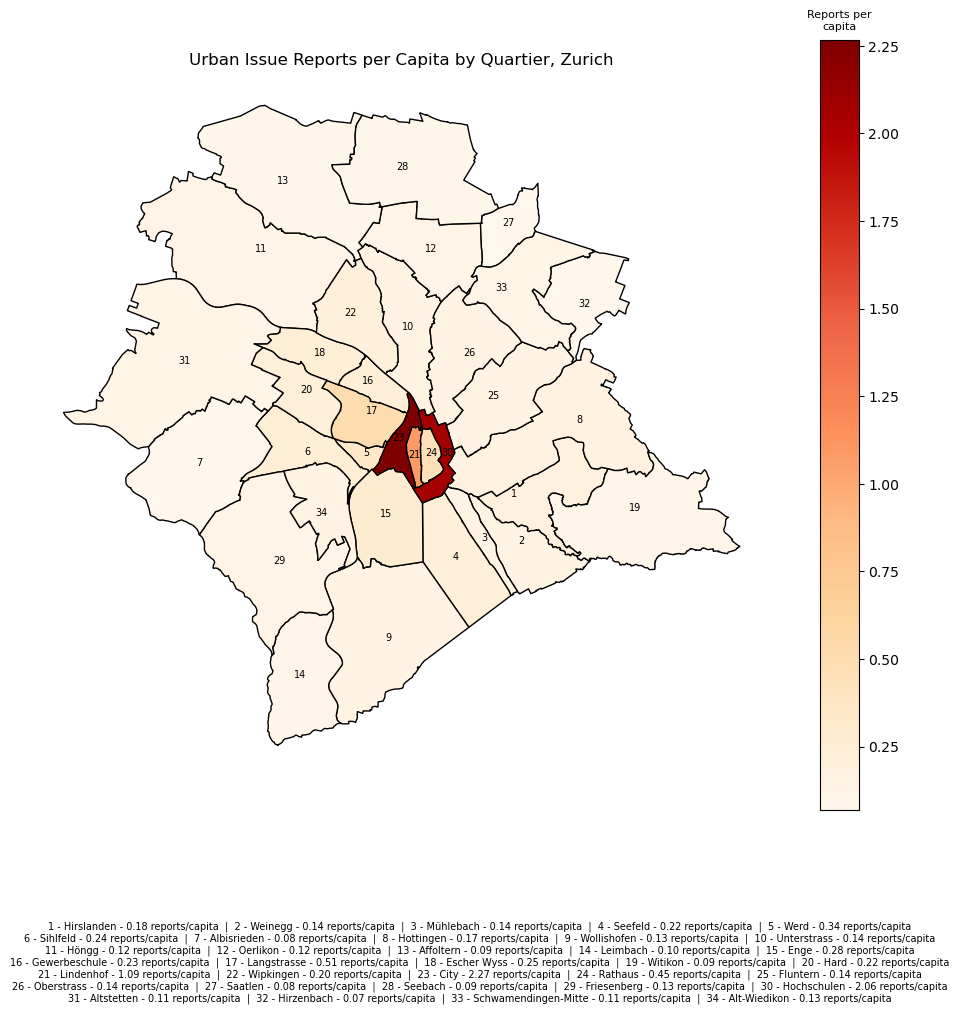

In [56]:
#figure axis
fig, ax = plt.subplots(figsize=(12, 10)) 

quartier_reports_per_capita.plot(
    column="reports_per_capita",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

#add a title to the scale bar
cbar = ax.get_figure().axes[1]  #when geopandas calls .plot(), it creates the main map axes and the colorbar axes
#the colorbar is the last axes object created. ax.get_figure() gets the figure that ax belongs to, .axes gets the list
#of all axes in that figure, and [1] grabs the last axis created
cbar.set_title("Reports per\ncapita", fontsize=8, pad=8)

#now we add label numbers to the middle of each quartier polygon
for idx, row in quartier_reports_per_capita.iterrows(): #tells python go through every row in the dataframe(idx is row number, rows contain values)
        middle_point = row.geometry.representative_point() #guarantees the point is inside the polygon, specifically designed for such sitations
        ax.text( #draw text on the map at the coordinates of each polygon centroid
            middle_point.x,#now the representative point coordinates rather than the centroid coordinates
            middle_point.y,
            str(row["label"]),#make row number the label of the polygon, str() used to convert labels from numbers to strings so matplotlib can process them
            ha="center", #horizontal alignment of the label is at the center, number on centroid point
            fontsize=7)

#add the annotation below the map
fig.text(
    0.5,
    -0.0005,
    annotation_q3,
    ha="center",
    va="top",
    fontsize=7,
    transform=fig.transFigure
)

#add the title and remove unneccesary axes to reduce clutter
ax.set_title("Urban Issue Reports per Capita by Quartier, Zurich")
ax.axis("off")

plt.show()

The map could be improved to be able to distinguish more between the lower end values. To do this, we will use cmcrameri color maps and define minimum and maximum values to stretch the color scale across the bulk of the data and not be compressed by outliers. In order to do this, we will first assess the data for extreme outliers first. 

In [57]:
print(quartier_reports_per_capita["reports_per_capita"].describe())

count    34.000000
mean      0.319766
std       0.503669
min       0.067873
25%       0.114701
50%       0.141577
75%       0.241104
max       2.265280
Name: reports_per_capita, dtype: float64


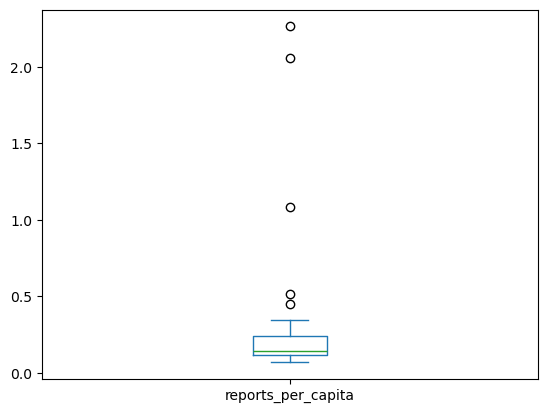

In [58]:
quartier_reports_per_capita["reports_per_capita"].plot(kind="box")
plt.show()

From this analysis, we can see that the bulk of the data is compressed as 50% of the quartiers sit between ~0.11 and ~0.24 reports per capita, while there are 3 significant outliers compressing the data with values of ~1.1, ~2.0, and ~2.3. We can redefine the upper quantile to cut off the large outliers from the color scale, making differences between lower report per capita values more distinguishable from one another. We can check the dataset and see what the next largest report per capita value is below ~1.1 to decide the vmax cutoff. 

In [59]:
print(quartier_reports_per_capita[["reports_per_capita"]].sort_values("reports_per_capita", ascending=False))

    reports_per_capita
22            2.265280
29            2.061047
20            1.085742
16            0.512690
23            0.449569
4             0.343730
14            0.275387
17            0.247899
5             0.244296
15            0.231528
19            0.223687
3             0.221283
21            0.197970
0             0.180443
7             0.168244
1             0.142080
2             0.141681
24            0.141473
9             0.140640
25            0.138081
33            0.133146
8             0.129012
28            0.127294
10            0.124134
11            0.123446
30            0.111786
32            0.107880
13            0.100222
18            0.094793
27            0.089802
12            0.088451
6             0.083731
26            0.077723
31            0.067873


We see that the next highest value is ~0.51, so we will make the vmax = 0.55. Now we can make the chloropleth map using cmcrameri color maps and add the vmax.

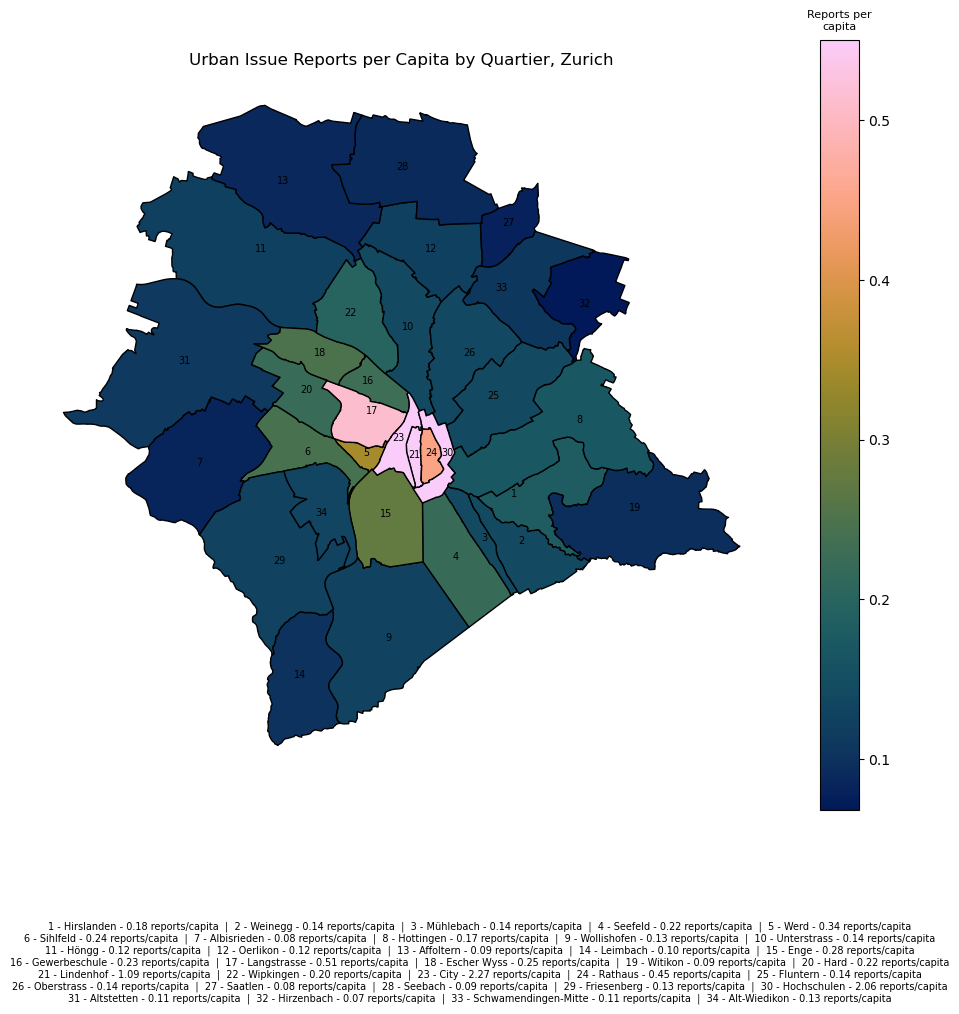

In [60]:
#figure axis
fig, ax = plt.subplots(figsize=(12, 10)) 

quartier_reports_per_capita.plot(
    column="reports_per_capita",
    cmap="cmc.batlow",
    legend=True,
    edgecolor="black",
    ax=ax,
    vmax=0.55
)

#add a title to the scale bar
cbar = ax.get_figure().axes[1]  #when geopandas calls .plot(), it creates the main map axes and the colorbar axes
#the colorbar is the last axes object created. ax.get_figure() gets the figure that ax belongs to, .axes gets the list
#of all axes in that figure, and [1] grabs the last axis created
cbar.set_title("Reports per\ncapita", fontsize=8, pad=8)

#now we add label numbers to the middle of each quartier polygon
for idx, row in quartier_reports_per_capita.iterrows(): #tells python go through every row in the dataframe(idx is row number, rows contain values)
        middle_point = row.geometry.representative_point() #guarantees the point is inside the polygon, specifically designed for such sitations
        ax.text( #draw text on the map at the coordinates of each polygon centroid
            middle_point.x,#now the representative point coordinates rather than the centroid coordinates
            middle_point.y,
            str(row["label"]),#make row number the label of the polygon, str() used to convert labels from numbers to strings so matplotlib can process them
            ha="center", #horizontal alignment of the label is at the center, number on centroid point
            fontsize=7)

#add the annotation below the map
fig.text(
    0.5,
    -0.0005,
    annotation_q3,
    ha="center",
    va="top",
    fontsize=7,
    transform=fig.transFigure
)

#add the title and remove unneccesary axes to reduce clutter
ax.set_title("Urban Issue Reports per Capita by Quartier, Zurich")
ax.axis("off")

plt.show()

Now we can save this map to the outputs folder. 

In [61]:
fig.savefig(
    "../outputs/issue_reports_per_capita_per_quartier.png",
    dpi=300,
    bbox_inches="tight"
)